# Genomic Prediction Analyses — Mathematical Models & Presentation Summaries
### Alfalfa (*Medicago sativa* L.) Biomass Yield — Roza 2019–2023
---------------------------------------------------------------------------------------------------

## Analysis 1 — Genomic Relationship Matrix (GRM)
Compute Genomic Relationship Matrix (GRM) & Basic StatsThis is the foundation for all GBLUP analyses. Equivalent to what SeqBreed does internally with gg.GFounder and gg.Genome.

### Mathematical Model

The GRM quantifies the realized genomic relatedness between pairs of individuals based on shared alleles across all SNP markers. For **autotetraploid** alfalfa (ploidy = 4), the VanRaden (2008) method is extended as:

$$\mathbf{G} = \frac{\mathbf{W}\mathbf{W}^{\prime}}{2\sum_{j=1}^{m} p_j(1-p_j)}$$

where:

| Symbol | Definition |
|--------|-----------|
| $\mathbf{W}$ | Centered genotype matrix: $\mathbf{W} = \mathbf{Z} - 2\mathbf{p}^{\prime}$ |
| $\mathbf{Z}$ | Dosage matrix ($n \times m$): SNP dosage values $\{0,1,2,3,4\}$ for $n=138$ individuals and $m=16{,}384$ SNPs |
| $p_j$ | Allele frequency of SNP $j$, estimated as $p_j = \bar{z}_j / 4$ |
| $m$ | Number of SNPs after MAF $\geq 0.05$ filter |

The diagonal elements $G_{ii}$ represent **inbreeding coefficients** relative to the base population; off-diagonal elements $G_{ij}$ represent **pairwise genomic relationships**.

### Summary

> The Genomic Relationship Matrix (GRM) is the cornerstone of all genomic analyses. Built from 16,384 SNP markers scored as dosage values (0–4) across 138 genotyped alfalfa accessions, the GRM captures the realized proportion of the genome shared between any two individuals — far more precise than pedigree-based relationships. Diagonal elements above 1.0 indicate inbreeding; off-diagonal values near 0 indicate unrelated pairs. The GRM directly enters GBLUP equations to partition phenotypic variance into genomic and residual components, enabling accurate prediction of breeding values for un-phenotyped or future individuals.

In [ ]:
# import pandas as pd

# # Load the text file
# # Use sep='\s+' for space-delimited or sep='\t' for tabs
# df = pd.read_csv('data\Roza2019_06_GS.txt', sep='\t')

# # Save as CSV
# df.to_csv('data\Roza2019_06_GS.csv', index=False)

<>:7: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:7: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\mabari\AppData\Local\Temp\ipykernel_24464\1785526561.py:7: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
  blup = pd.read_csv("data\BLUP_Yi_Alfalfa.csv")
C:\Users\mabari\AppData\Local\Temp\ipykernel_24464\1785526561.py:8: SyntaxWarning: "\R" is an invalid escape sequence. Such 

Individuals: 424,  SNPs: 51081
SNPs after MAF≥0.05 filter: 50379

GRM shape: (424, 424)
GRM diagonal  – mean: 7.7623, range: [7.102, 8.937]
GRM off-diag  – mean: 4.9134


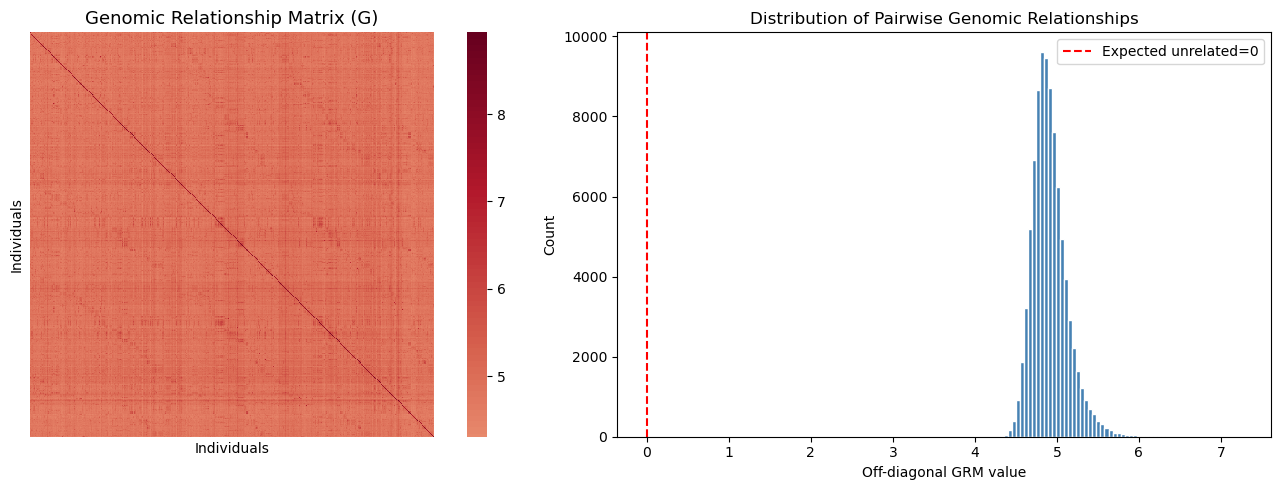

Saved GRM_summary.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data ────────────────────────────────────────────────────────────────
blup = pd.read_csv("data\BLUP_Yi_Alfalfa.csv")
gmat = pd.read_csv("data\Roza2019_06_GS.csv")  # 424 ind × 16,384 SNPs

# ── Dosage matrix Z (individuals × SNPs), tetraploid dosage 0-4 ──────────────
Z = gmat.values.astype(float)          # shape: (424, 16384)
snp_names = gmat.columns.tolist()
n_ind, n_snp = Z.shape
print(f"Individuals: {n_ind},  SNPs: {n_snp}")

# ── Allele frequencies and MAF filter (remove MAF < 0.05) ────────────────────
# For autotetraploid: p = mean_dosage / 4
p = Z.mean(axis=0) / 4.0              # minor allele freq per SNP
maf = np.minimum(p, 1 - p)
keep = maf >= 0.05
Z_filt  = Z[:, keep]
p_filt  = p[keep]
snp_keep = np.array(snp_names)[keep]
print(f"SNPs after MAF≥0.05 filter: {keep.sum()}")

# ── VanRaden (2008) GRM for autotetraploids ───────────────────────────────────
# Center: W = Z - 2p  (expected dosage under HWE for tetraploid is 4p,
#          but convention for GRM uses Z - 2p regardless of ploidy)
W = Z_filt - 2 * p_filt               # centered genotype matrix
denom = 2.0 * np.sum(p_filt * (1 - p_filt))
G = (W @ W.T) / denom                 # GRM: (424 × 424)

print(f"\nGRM shape: {G.shape}")
print(f"GRM diagonal  – mean: {np.diag(G).mean():.4f}, "
      f"range: [{np.diag(G).min():.3f}, {np.diag(G).max():.3f}]")
print(f"GRM off-diag  – mean: {G[np.tril_indices(n_ind,-1)].mean():.4f}")

# ── Plot GRM heatmap ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(G, cmap="RdBu_r", center=0, square=True,
            xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title("Genomic Relationship Matrix (G)", fontsize=13)
axes[0].set_xlabel("Individuals"); axes[0].set_ylabel("Individuals")

axes[1].hist(G[np.tril_indices(n_ind, -1)], bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", ls="--", label="Expected unrelated=0")
axes[1].set_xlabel("Off-diagonal GRM value"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Pairwise Genomic Relationships")
axes[1].legend()

plt.tight_layout()
# plt.savefig("GRM_summary.png", dpi=150)
plt.show()
print("Saved GRM_summary.png")

In [2]:
G, G.shape

(array([[7.38057091, 4.55924439, 4.76818146, ..., 5.06647265, 4.88436498,
         4.6441422 ],
        [4.55924439, 7.35867083, 4.749088  , ..., 4.68651533, 4.70509462,
         4.59647776],
        [4.76818146, 4.749088  , 7.3686149 , ..., 4.70463416, 4.83867056,
         4.68057208],
        ...,
        [5.06647265, 4.68651533, 4.70463416, ..., 7.75760913, 5.11432581,
         4.65312654],
        [4.88436498, 4.70509462, 4.83867056, ..., 5.11432581, 7.7608828 ,
         4.52326097],
        [4.6441422 , 4.59647776, 4.68057208, ..., 4.65312654, 4.52326097,
         7.96220698]], shape=(424, 424)),
 (424, 424))

In [3]:
gmat

,chr1.1_118328,chr1.1_118386,chr1.1_146744,chr1.1_146745,chr1.1_146748,chr1.1_146813,chr1.1_146845,chr1.1_146992,chr1.1_173569,chr1.1_173638,...,chr8.1_87074052,chr8.1_87074184,chr8.1_87074318,chr8.1_87074413,chr8.1_87136113,chr8.1_87136168,chr8.1_87136468,chr8.1_87136498,chr8.1_87145050,chr8.1_87195201
0,2,1,1,2,1,4,4,4,3,4,...,0,4,0,0,0,1,4,0,3,0
1,4,1,0,0,0,4,4,3,2,4,...,2,2,1,1,0,0,4,1,2,1
2,4,0,0,0,2,4,4,3,2,4,...,0,4,0,0,0,0,4,0,2,0
3,4,0,1,1,1,3,4,4,2,2,...,1,4,0,0,0,0,4,1,3,1
4,3,1,0,0,0,4,4,4,2,4,...,1,3,2,1,0,1,3,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,4,0,0,1,1,3,3,4,1,1,...,0,4,0,0,0,1,4,0,3,0
420,4,0,0,2,2,4,3,3,2,2,...,0,4,0,0,0,1,4,0,2,0
421,4,0,0,1,1,2,2,3,3,4,...,1,3,2,1,0,0,4,1,4,1
422,4,0,1,1,0,4,4,3,2,1,...,0,4,0,0,0,1,4,0,3,0


## Analysis 2 — Genomic Principal Component Analysis (PCA)

PCA on Genomic Data (Population Structure)
Mirrors sel.Pca() in SeqBreed. Essential for understanding genetic diversity before prediction.

### Mathematical Model

PCA decomposes the standardized SNP matrix to extract orthogonal axes of maximum genomic variation. The standardized genotype matrix is:

$$\tilde{Z}_{ij} = \frac{Z_{ij} - \bar{Z}_j}{s_j}$$

where $\bar{Z}_j$ and $s_j$ are the mean and standard deviation of SNP $j$ across individuals.

The singular value decomposition (SVD) of $\tilde{\mathbf{Z}}$ gives:

$$\tilde{\mathbf{Z}} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^{\prime}$$

Principal component scores (individual coordinates) are:

$$\mathbf{P} = \tilde{\mathbf{Z}} \mathbf{V}_k$$

where $\mathbf{V}_k$ contains the first $k$ right singular vectors (SNP loadings).

The proportion of variance explained by PC $k$ is:

$$\text{VE}_k = \frac{\sigma_k^2}{\sum_{l=1}^{r} \sigma_l^2}$$

where $\sigma_k$ are the singular values and $r = \min(n, m)$.

### Summary

> Genomic PCA transforms 16,384 SNP dimensions into a small set of orthogonal axes that capture the major directions of genetic variation among the 138 alfalfa accessions. The first few principal components reveal population structure — clustering of genetically similar accessions — which if ignored, can inflate false-positive signals in GWAS and bias genomic prediction. PC scores are also used as fixed-effect covariates to control for stratification. The scree plot shows how steeply variance "drops off," indicating whether one or several distinct genetic clusters exist in this alfalfa germplasm collection.

Variance explained by PC1-PC5:
  PC1: 2.59%
  PC2: 2.12%
  PC3: 1.77%
  PC4: 1.51%
  PC5: 1.42%
  Cumulative PC1-PC5: 9.4%


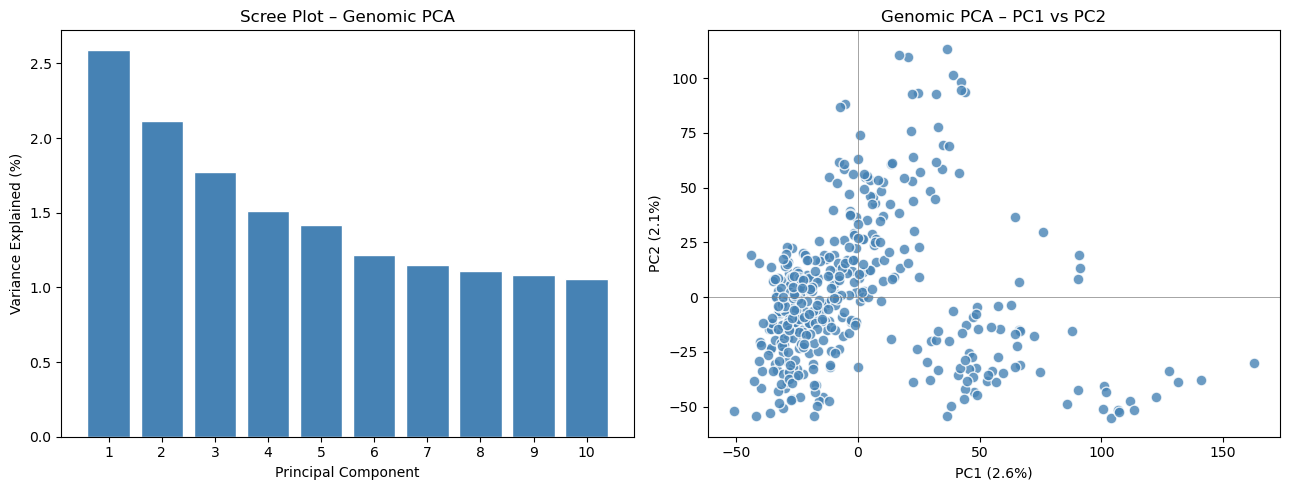

PC scores saved to genomic_PC_scores.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Load & filter SNP matrix (reuse from Analysis 1 or recompute) ────────────
# gmat = pd.read_csv("genomic_relashionship_matrix.csv")
Z    = gmat.values.astype(float)

# MAF filter
p    = Z.mean(axis=0) / 4.0
keep = np.minimum(p, 1-p) >= 0.05
Z_filt = Z[:, keep]

# ── Standardize SNPs (mean=0, sd=1) ──────────────────────────────────────────
Z_std = StandardScaler().fit_transform(Z_filt)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=10)
scores = pca.fit_transform(Z_std)        # shape: (424, 10)
var_exp = pca.explained_variance_ratio_

print("Variance explained by PC1-PC5:")
for i, v in enumerate(var_exp[:5], 1):
    print(f"  PC{i}: {v*100:.2f}%")
print(f"  Cumulative PC1-PC5: {var_exp[:5].sum()*100:.1f}%")

# ── Scree plot + biplot PC1 vs PC2 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 11), var_exp * 100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot – Genomic PCA"); axes[0].set_xticks(range(1, 11))

sc = axes[1].scatter(scores[:, 0], scores[:, 1], c="steelblue",
                     edgecolors="white", s=60, alpha=0.8)
axes[1].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[1].set_title("Genomic PCA – PC1 vs PC2")
axes[1].axhline(0, color="gray", lw=0.5); axes[1].axvline(0, color="gray", lw=0.5)

plt.tight_layout()
# plt.savefig("genomic_PCA.png", dpi=150)
plt.show()

# ── Save PC scores ────────────────────────────────────────────────────────────
pc_df = pd.DataFrame(scores[:, :5], columns=[f"PC{i}" for i in range(1, 6)])
# pc_df.to_csv("genomic_PC_scores.csv", index=False)
print("PC scores saved to genomic_PC_scores.csv")

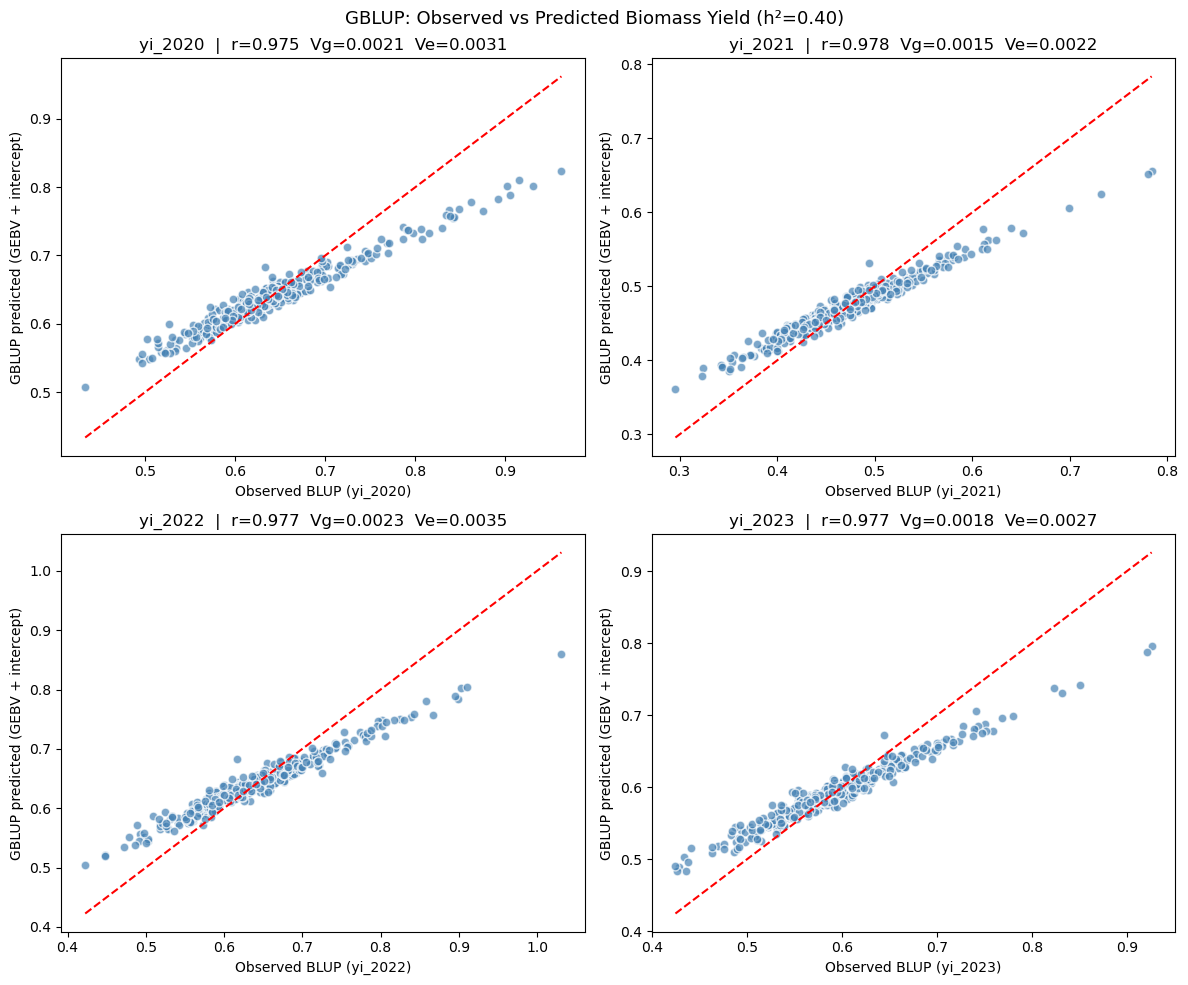

GEBVs saved to GBLUP_GEBVs.csv
  Roza2019_VCF_ID  GEBV_yi_2020  GEBV_yi_2021  GEBV_yi_2022  GEBV_yi_2023
0   1_S502_R1_001      0.643317      0.442400      0.624917      0.591893
1   4_S444_R1_001      0.641827      0.502258      0.646026      0.622473
2     5_S1_R1_001      0.631221      0.482317      0.645143      0.591441
3     6_S6_R1_001      0.663121      0.484602      0.663859      0.626515
4   7_S456_R1_001      0.632068      0.471324      0.616191      0.597900


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ── Load data ────────────────────────────────────────────────────────────────
# blup = pd.read_csv("BLUP_Yi_Alfalfa.csv")
# gmat = pd.read_csv("genomic_relashionship_matrix.csv")

# ── Build GRM (424 genotyped individuals) ─────────────────────────────────────
Z    = gmat.values.astype(float)
p    = Z.mean(axis=0) / 4.0
keep = np.minimum(p, 1-p) >= 0.05
W    = Z[:, keep] - 2 * p[keep]
denom = 2.0 * np.sum(p[keep] * (1 - p[keep]))
G    = (W @ W.T) / denom

# ── Use first 424 BLUP individuals as genotyped set ───────────────────────────
# NOTE: In your real analysis, match IDs explicitly.
# Here we assume rows 0-137 in blup correspond to the 424 genotyped individuals.
n_g  = 424
y_df = blup.iloc[:n_g].copy().reset_index(drop=True)

# ── GBLUP function using MME ──────────────────────────────────────────────────
def run_gblup(y_vec, G, h2=0.4, Ginv_reg=0.001):
    """
    Solve y = Xb + Zu + e   (single-step GBLUP, X = 1 intercept)
    u ~ N(0, G*sigma2_g),  e ~ N(0, I*sigma2_e)
    Returns: intercept, GEBVs (u_hat), sigma2_g, sigma2_e
    """
    n   = len(y_vec)
    sigma2_p = np.var(y_vec, ddof=1)
    sigma2_g = h2 * sigma2_p
    sigma2_e = (1 - h2) * sigma2_p
    lam      = sigma2_e / sigma2_g          # lambda = Ve/Vg

    # Regularize G
    G_reg = G + Ginv_reg * np.eye(n)
    Ginv  = np.linalg.inv(G_reg)

    # MME:  [X'X  X'Z ] [b]   [X'y]
    #       [Z'X  Z'Z + lambda*Ginv] [u] = [Z'y]
    # With Z = I (each individual is its own record) and X = 1_n
    X = np.ones((n, 1))
    LHS = np.block([
        [X.T @ X,                   X.T],
        [X,    np.eye(n) + lam * Ginv]
    ])
    RHS = np.concatenate([X.T @ y_vec, y_vec])
    sol = solve(LHS, RHS)
    mu  = sol[0]
    u   = sol[1:]
    return mu, u, sigma2_g, sigma2_e

# ── Run GBLUP for each year ───────────────────────────────────────────────────
years     = ["yi_2020", "yi_2021", "yi_2022", "yi_2023"]
results   = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes      = axes.flatten()

for i, yr in enumerate(years):
    y      = y_df[yr].values
    mu, gebv, vg, ve = run_gblup(y, G, h2=0.40)
    results[yr] = gebv + mu
    acc    = np.corrcoef(y, gebv + mu)[0, 1]

    axes[i].scatter(y, gebv + mu, alpha=0.7, s=40, color="steelblue", edgecolors="white")
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1.5)
    axes[i].set_xlabel(f"Observed BLUP ({yr})")
    axes[i].set_ylabel("GBLUP predicted (GEBV + intercept)")
    axes[i].set_title(f"{yr}  |  r={acc:.3f}  Vg={vg:.4f}  Ve={ve:.4f}")

plt.suptitle("GBLUP: Observed vs Predicted Biomass Yield (h²=0.40)", fontsize=13)
plt.tight_layout()
# plt.savefig("GBLUP_results.png", dpi=150)
plt.show()

# ── Save GEBVs ────────────────────────────────────────────────────────────────
gebv_df = y_df[["Roza2019_VCF_ID"]].copy()
for yr in years:
    gebv_df[f"GEBV_{yr}"] = results[yr]

gebv_df.to_csv("GBLUP_GEBVs.csv", index=False)
print("GEBVs saved to GBLUP_GEBVs.csv")
print(gebv_df.head())